In [1]:
import numpy as np
from pathlib import Path

In [ ]:
floder = Path("/home/tony/mine/Projects/ArmHandVis/HandVersion/HandArmFiles/ARM_HAND_URDF/transform_data")
file1 = Path("cam0_camera_base -> cam0_camera_body.txt")
file2 = Path("ra_shoulder_link -> ra_upper_arm_link.txt")
file_path = floder / file1
content = np.loadtxt(file_path, dtype=np.float32)
print(content)
print(content.reshape((1,8)))

IndexError: tuple index out of range


KeyboardInterrupt



In [ ]:
import rosbag
import xml.etree.ElementTree as ET
from pathlib import Path
from pprint import pprint
from cv_bridge import CvBridge
import cv2,re
from sensor_msgs.msg import Image
import numpy as np
import matplotlib.pylab as plt
import open3d as o3d
from tqdm import tqdm
import math,copy
import os
from numba import jit
import scipy
from scipy.spatial.transform import Rotation
import pywavefront
import sensor_msgs.point_cloud2 as pc2
import ctypes
import struct
import Ros_Analysis
from collections import defaultdict

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/usr/local/lib/python3.8/dist-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/usr/local/lib/python3.8/dist-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/usr/local/lib/python3.8/dist-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/usr/local/lib/python3.8/dist-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


In [ ]:


rotation = Rotation.from_quat(quat).as_matrix()

In [ ]:
bag_path = "/home/tony/mine/Projects/ArmHandVis/HandVersion/HandArmFiles/ARM_HAND_URDF/meal_spoon_0_20230921.bag"
bagdata = rosbag.Bag(bag_path)
for _,msg,_ in bagdata.read_messages(topics=['/cam0/rgb/camera_info']):
    print(msg)

NameError: name 'rosbag' is not defined

In [ ]:
transform = {
    "cam0_camera_base":np.array([
        [
            -0.7830674863414276,
            -0.3169344561946968,
            -0.5351241559783019,
            1.97166146
        ],
        [
            0.16158911085006195,
            -0.9345458620314356,
            0.31703783845876693,
            -0.14104375
        ],
        [
            -0.6005782805676579,
            0.16179178667810257,
            0.783025636025988,
            1.27084793
        ],
        [
            0.0,
            0.0,
            0.0,
            1.0
        ]
    ]),
    "ra_base_link":np.array([
        [
            1.0,
            0.0,
            0.0,
            0.0
        ],
        [
            0.0,
            1.0,
            0.0,
            0.0
        ],
        [
            0.0,
            0.0,
            1.0,
            0.7551
        ],
        [
            0.0,
            0.0,
            0.0,
            1.0
        ]
    ])
    ,"ICP_transform":np.array(
        [
        [ 9.99999597e-01,  7.85177098e-04,  4.35498336e-04, -8.68879711e-05],
        [-7.87157661e-04,  9.99989264e-01,  4.56643530e-03, -4.36117045e-03],
        [-4.31908200e-04, -4.56677627e-03,  9.99989479e-01,  8.34490015e-04],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00]
        ]
    ),
    "cam0_depth_link":np.array([
        [
            0.31693445619469673,
            0.6140455308430225,
            -0.722842055035734,
            1.970698236535785
        ],
        [
            0.934545862031436,
            -0.33219173344541675,
            0.12756443074168414,
            -0.140473081900577
        ],
        [
            -0.16179178667810235,
            -0.7159586149228463,
            -0.6791367163401397,
            1.2722573761206357
        ],
        [
            0.0,
            0.0,
            0.0,
            1.0
        ]
    ])
}

In [ ]:
print(transform["ICP_transform"] @ transform["cam0_depth_link"])
correct_result = transform["ICP_transform"] @ transform["cam0_depth_link"]

[[ 0.31759765  0.61347266 -0.72303737  1.97105432]
 [ 0.93354754 -0.3359409   0.12503082 -0.14057431]
 [-0.16619483 -0.71469925 -0.67939993  1.27286883]
 [ 0.          0.          0.          1.        ]]


In [ ]:
cam0_base_link2cam0depth_link = np.linalg.inv(transform["cam0_camera_base"])@transform["cam0_depth_link"]

In [ ]:

ra_base_ling2cam0_base_link = np.linalg.inv(transform["ra_base_link"])@correct_result @np.linalg.inv(cam0_base_link2cam0depth_link)
print(ra_base_ling2cam0_base_link)

[[-0.78320185 -0.31759765 -0.534534    1.97201649]
 [ 0.15946127 -0.93354754  0.3210313  -0.14115217]
 [-0.60097169  0.16619483  0.78180068  0.51636159]
 [ 0.          0.          0.          1.        ]]


In [ ]:
quer = Rotation.from_matrix(ra_base_ling2cam0_base_link[:3,:3]).as_quat()

In [ ]:
print(quer)

[-0.30353954  0.13024364  0.93522057  0.12752578]


In [ ]:
test = np.array([[999, 1.97166146, -0.14104375 ,0.51574793, -0.30350154 , 0.12796092,  0.93549973 , 0.12787913]])
print(test.shape)

(1, 8)


In [ ]:
import json
import numpy as np

data = {"name": np.array([[1, 2, 3, 4],
                          [5, 6, 7, 8],
                          [9, 10, 11, 12],
                          [13, 14, 15, 16]])}

# 将numpy数组转换为列表，以便能够序列化为JSON格式
data_serializable = {key: value.tolist() if isinstance(value, np.ndarray) else value for key, value in data.items()}

# 保存为JSON文件
file_path = '/home/tony/mine/Projects/ArmHandVis/HandVersion/HandArmFiles/ARM_HAND_URDF/banana/data.json'
with open(file_path, 'w') as file:
    json.dump(data_serializable, file, indent=4)


In [ ]:
# 加载JSON文件
with open(file_path, 'r') as file:
    loaded_data = json.load(file)

# 将列表转换为numpy数组
loaded_data = {key: np.array(value) if isinstance(value, list) else value for key, value in loaded_data.items()}

print(loaded_data)

{'name': array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16]])}


In [1]:
import open3d as o3d
from scipy.spatial.transform import Rotation 
import numpy as np
global_cam0_depth_link = np.array([
        [
            0.2062293800506934,
            -0.9750813380044167,
            -0.08176690699435685,
            -0.30190442395306816
        ],
        [
            0.9565750909433249,
            0.18331090742002934,
            0.22663010966686586,
            -0.2097745028083595
        ],
        [
            -0.20599402464799044,
            -0.12495397351169962,
            0.9705426143724764,
            0.4185898762414926
        ],
        [
            0.0,
            0.0,
            0.0,
            1.0
        ]
    ])

mesh_transform = np.array([
[0.998721, 0.014314, 0.048494 ,-0.062890],
[-0.012437, 0.999171 ,-0.038775 ,0.099689],
[-0.049009 ,0.038122, 0.998071, 0.137977],
[0.000000 ,0.000000, 0.000000 ,1.000000]
])
mesh_transform = np.linalg.inv(mesh_transform)
result_transform = np.linalg.inv(global_cam0_depth_link) @ mesh_transform
def transform_mesh_with_matrix(transform_matrix,mesh):
    vertices = np.asarray(mesh.vertices).copy() 
    vertices = np.hstack((vertices,np.ones((vertices.shape[0],1))),dtype=float).T
    transformed_vertices = np.dot(transform_matrix[:3,:],vertices).T
    mesh.vertices = o3d.utility.Vector3dVector(transformed_vertices)
    return mesh
print(result_transform)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[[ 0.20966782  0.96120361 -0.17923673  0.29124877]
 [-0.97726977  0.2001316  -0.06993706 -0.27538466]
 [-0.03135279  0.18982651  0.98131652 -0.53969839]
 [ 0.          0.          0.          1.        ]]


In [2]:
quat = Rotation.from_matrix(result_transform[:3,:3]).as_quat()
print(quat[[3,0,1,2]])
print(result_transform[:3,3])
# file_path = "/home/tony/mine/Projects/ArmHandVis/HandVersion/HandArmFiles/ARM_HAND_URDF/banana/cam0/points2/0.ply"
# banana_mesh = o3d.io.read_triangle_mesh(file_path)
# banana_mesh = transform_mesh_with_matrix(np.linalg.inv(global_cam0_rgb_link),banana_mesh)
# o3d.io.write_triangle_mesh("/home/tony/mine/Projects/ArmHandVis/HandVersion/HandArmFiles/ARM_HAND_URDF/banana/transoform_cam0_0_world.ply",banana_mesh)


[ 0.77316178  0.08399395 -0.04781793 -0.62680086]
[ 0.29124877 -0.27538466 -0.53969839]


In [3]:
print(result_transform)

[[-0.01968271 -0.9733047   0.22866906  0.45563402]
 [ 0.15393809 -0.22893671 -0.96119212  1.46370683]
 [ 0.98788434  0.01628138  0.15433496 -0.56657183]
 [ 0.          0.          0.          1.        ]]


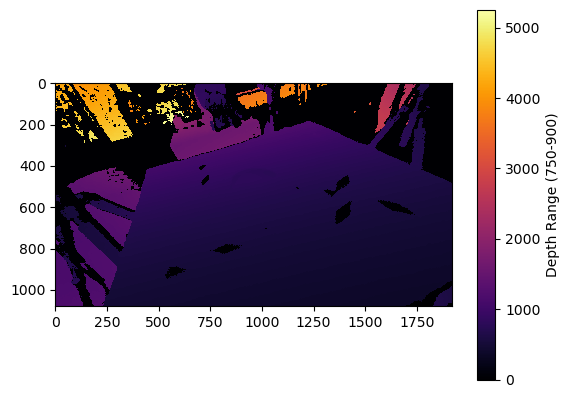

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(threshold=np.inf)
# 读取PNG图像并以unchanged方式加载
image = cv2.imread('/home/tony/mine/Projects/ArmHandVis/HandVersion/HandArmFiles/ARM_HAND_URDF/back_banana/banana/cam0/depth_to_rgb/image_raw/0.png', cv2.IMREAD_UNCHANGED)
# image = np.array(image)
# print(image.shape)


# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# image[image > 900 ] = 0
# image[image < 750 ] = 0
# image = (image - np.min(image))/(np.max(image) - np.min(image)) * 65535
# 用matplotlib显示图片
plt.imshow(image,cmap = 'inferno')
cbar = plt.colorbar()
cbar.set_label('Depth Range (750-900)')
plt.show()


In [ ]:
image2 = cv2.imread('/media/tony/T7/暂时存放/ProjectRecorded8_28_2023/ICG+_TestOnOurData/depth/000001-depth.png', cv2.IMREAD_UNCHANGED)
image_array2 = np.max(np.array(image2))
print(image_array2)

64928


In [ ]:
import numpy as np
import open3d as o3d
from scipy.spatial.transform import Rotation
from copy import deepcopy
global_cam0_rgb_link = np.array([
        [
            0.3177631396575807,
            0.5482849928961032,
            -0.7735697471074461,
            1.9851580584545925
        ],
        [
            0.9341766235227087,
            -0.3206862662476205,
            0.156442816082659,
            -0.11198192996679562
        ],
        [
            -0.16229794557747576,
            -0.7723625348274484,
            -0.6140972981997643,
            1.2676387525540525
        ],
        [
            0.0,
            0.0,
            0.0,
            1.0
        ]
    ])

def seven_num2matrix(translation,roatation):#translation x,y,z rotation x,y,z,w
    transform_matrix = np.identity(4)
    transform_matrix[:3,:3] = Rotation.from_quat(roatation).as_matrix()
    transform_matrix[:3,3] = translation
    return transform_matrix

def transform_mesh_with_matrix(transform_matrix,mesh):
    vertices = np.asarray(mesh.vertices).copy() 
    vertices = np.hstack((vertices,np.ones((vertices.shape[0],1))),dtype=float).T
    transformed_vertices = np.dot(transform_matrix[:3,:],vertices).T
    mesh.vertices = o3d.utility.Vector3dVector(transformed_vertices)
    return mesh

banana_mesh_path = "/home/tony/mine/Projects/ArmHandVis/HandVersion/HandArmFiles/ARM_HAND_URDF/banana/banana.ply"
banana_mesh = o3d.io.read_triangle_mesh(banana_mesh_path)

path = "/home/tony/mine/Projects/ArmHandVis/HandVersion/HandArmFiles/ARM_HAND_URDF/banana/world -> banana.txt"
banana_in_rgb_camera0 = np.loadtxt(path,dtype=np.float128)
transforms = []
for index in np.arange(banana_in_rgb_camera0.shape[0]):
    temp_transform = seven_num2matrix(banana_in_rgb_camera0[index,4:],np.hstack((banana_in_rgb_camera0[index,1:4],banana_in_rgb_camera0[index,0])))
    temp_transform = global_cam0_rgb_link@temp_transform
    transform_banana_mesh = transform_mesh_with_matrix(temp_transform,deepcopy(banana_mesh))
    o3d.io.write_triangle_mesh(f"/home/tony/mine/Projects/ArmHandVis/HandVersion/HandArmFiles/ARM_HAND_URDF/banana/banana_mesh/{index}.ply",transform_banana_mesh)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
from pathlib import Path
bag_path = Path('banana').joinpath(Path('.bag'))
print(bag_path) 

banana/.bag


In [ ]:
from imageio.v3 import imread
import cv2
path = "/home/tony/mine/Projects/ArmHandVis/HandVersion/HandArmFiles/ARM_HAND_URDF/banana/cam0/rgb/image_raw/0.png"
imageio_image = imread(path)
cv2_image = cv2.imread(path)

print(imageio_image[100,150])
print("")
print(cv2_image[100,150])

[247 239 216]

[216 239 247]
